In [1]:
# MASK R-CNN TRANSFER LEARNING — labels 1-5, background=0

In [2]:
import os, gc, json, time, random, numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import cv2, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import torchvision.transforms.functional as F
from tqdm import tqdm
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# =========================================================
# PATHS — new balanced preprocessed dataset (labels 1-5)
# =========================================================
PRUNED_PATH  = "/kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset"
PREPROC_PATH = "/kaggle/input/datasets/harshitabansal307/task2-preprocessed-detetcion-segmentation/preprocessed"

train_pt = os.path.join(PREPROC_PATH, "train_detection_samples_balanced.pt")
val_pt   = os.path.join(PREPROC_PATH, "val_detection_samples_balanced.pt")

train_data = torch.load(train_pt, map_location="cpu")
val_data   = torch.load(val_pt,   map_location="cpu")

print("Train samples:", len(train_data))
print("Val samples:  ", len(val_data))
print("Sample keys:  ", train_data[0].keys())
all_lbls = [l for s in train_data for l in s["labels"]]
print("Label range:  ", min(all_lbls), "-", max(all_lbls), "(should be 1-5)")

Train samples: 20000
Val samples:   5000
Sample keys:   dict_keys(['img_path', 'boxes', 'labels', 'polygons'])
Label range:   1 - 5 (should be 1-5)


In [4]:
# =========================================================
# CATEGORY MAP
# Labels in .pt files are ALREADY 1-5 (from new preprocessing)
# Background = 0 (implicit, not annotated)
# No remapping needed — just passthrough
# =========================================================
CATEGORY_MAP = {1:1, 2:2, 3:3, 4:4, 5:5}

NUM_CLASSES = 5

CLASS_NAMES = [
    "__background__",   # 0
    "short_sleeve_top", # 1
    "trousers",         # 2
    "shorts",           # 3
    "long_sleeve_top",  # 4
    "skirt",            # 5
]

label_map = {
    "short sleeve top": 1,
    "trousers":         2,
    "shorts":           3,
    "long sleeve top":  4,
    "skirt":            5,
}
with open("/kaggle/working/label_map.json", "w") as f:
    json.dump(label_map, f, indent=4)
print("label_map.json saved")
print("Category map:", CATEGORY_MAP)

label_map.json saved
Category map: {1: 1, 2: 2, 3: 3, 4: 4, 5: 5}


In [5]:
# =========================================================
# POLYGON → BINARY MASK (per instance)
# Scales polygon coordinates to resized image dimensions
# =========================================================
def polygon_to_mask(poly_list, h, w, scale_x=1.0, scale_y=1.0):
    mask = np.zeros((h, w), dtype=np.uint8)
    for poly in poly_list:
        pts = np.array(poly).reshape(-1, 2).astype(np.float32)
        pts[:, 0] *= scale_x
        pts[:, 1] *= scale_y
        pts = pts.astype(np.int32)
        cv2.fillPoly(mask, [pts], 1)   # binary: 1=clothing pixel, 0=background
    return mask

In [6]:
# =========================================================
# DATASET
# Target dict per image:
#   boxes    : FloatTensor [N,4]  x1,y1,x2,y2
#   labels   : Int64Tensor [N]    values 1-5
#   masks    : UInt8Tensor [N,H,W] binary per instance
#   image_id : Int64Tensor [1]
#   area     : FloatTensor [N]
#   iscrowd  : Int64Tensor [N]
# =========================================================
class DeepFashionMRCNN(Dataset):

    def __init__(self, data, augment=True):
        self.data    = data
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        img = cv2.imread(sample["img_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = img.shape[:2]

        img = cv2.resize(img, (512, 512))
        h, w = 512, 512
        scale_x = w / orig_w
        scale_y = h / orig_h

        flip = self.augment and random.random() > 0.5
        if flip:
            img = np.fliplr(img).copy()

        boxes, labels, masks, areas = [], [], [], []

        for raw_label, poly_list in zip(sample["labels"], sample["polygons"]):
            cls = CATEGORY_MAP.get(int(raw_label))
            if cls is None:
                continue

            mask = polygon_to_mask(poly_list, h, w, scale_x, scale_y)
            if flip:
                mask = np.fliplr(mask).copy()

            ys, xs = np.where(mask)
            if len(xs) == 0:
                continue

            x1, x2 = int(xs.min()), int(xs.max())
            y1, y2 = int(ys.min()), int(ys.max())

            if x2 <= x1 or y2 <= y1:
                continue

            boxes.append([x1, y1, x2, y2])
            labels.append(cls)
            masks.append(mask)
            areas.append((x2 - x1) * (y2 - y1))

        img_tensor = F.to_tensor(Image.fromarray(img))

        if len(boxes) == 0:
            target = {
                "boxes":    torch.zeros((0, 4), dtype=torch.float32),
                "labels":   torch.zeros((0,),   dtype=torch.int64),
                "masks":    torch.zeros((0, h, w), dtype=torch.uint8),
                "image_id": torch.tensor([idx],  dtype=torch.int64),
                "area":     torch.zeros((0,),    dtype=torch.float32),
                "iscrowd":  torch.zeros((0,),    dtype=torch.int64),
            }
        else:
            target = {
                "boxes":    torch.tensor(boxes,  dtype=torch.float32),
                "labels":   torch.tensor(labels, dtype=torch.int64),
                "masks":    torch.tensor(np.stack(masks), dtype=torch.uint8),
                "image_id": torch.tensor([idx],  dtype=torch.int64),
                "area":     torch.tensor(areas,  dtype=torch.float32),
                "iscrowd":  torch.zeros((len(boxes),), dtype=torch.int64),
            }
        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

In [7]:
train_dataset = DeepFashionMRCNN(train_data, augment=True)
val_dataset   = DeepFashionMRCNN(val_data,   augment=False)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False,
                          num_workers=2, collate_fn=collate_fn, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))

Train batches: 10000
Val batches:   2500


In [8]:
def build_model_transfer(num_classes):
    model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
    for p in model.backbone.body.parameters(): p.requires_grad = False
    for p in model.backbone.fpn.parameters():  p.requires_grad = False
    in_box  = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_box, num_classes)
    in_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_mask, 256, num_classes)
    return model

model = build_model_transfer(NUM_CLASSES + 1).to(device)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total: {total/1e6:.1f}M  Trainable: {trainable/1e6:.1f}M (backbone frozen)")

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 213MB/s]


Total: 43.9M  Trainable: 17.1M (backbone frozen)


In [9]:
torch.cuda.empty_cache(); gc.collect()

EPOCHS = 8
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005, momentum=0.9, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

train_losses = []
start_time   = time.time()

for epoch in range(EPOCHS):
    model.train()
    epoch_loss, n_batches = 0.0, 0

    for imgs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs    = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        losses    = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        epoch_loss += losses.item()
        n_batches  += 1
        del imgs, targets, loss_dict, losses
        torch.cuda.empty_cache()

    lr_scheduler.step()
    avg_loss = epoch_loss / n_batches
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")

train_time = time.time() - start_time
print(f"Training time: {train_time/60:.1f} mins")

Epoch 1/8: 100%|██████████| 10000/10000 [48:17<00:00,  3.45it/s]


Epoch 1 | Loss: 0.4911


Epoch 2/8: 100%|██████████| 10000/10000 [48:45<00:00,  3.42it/s]


Epoch 2 | Loss: 0.4283


Epoch 3/8: 100%|██████████| 10000/10000 [48:43<00:00,  3.42it/s]


...

Epoch 6 | Loss: 0.3601


Epoch 7/8: 100%|██████████| 10000/10000 [48:44<00:00,  3.42it/s]


Epoch 7 | Loss: 0.3541


Epoch 8/8: 100%|██████████| 10000/10000 [48:43<00:00,  3.42it/s]

Epoch 8 | Loss: 0.3543
Training time: 389.5 mins


Saved: maskrcnn_transfer.pth


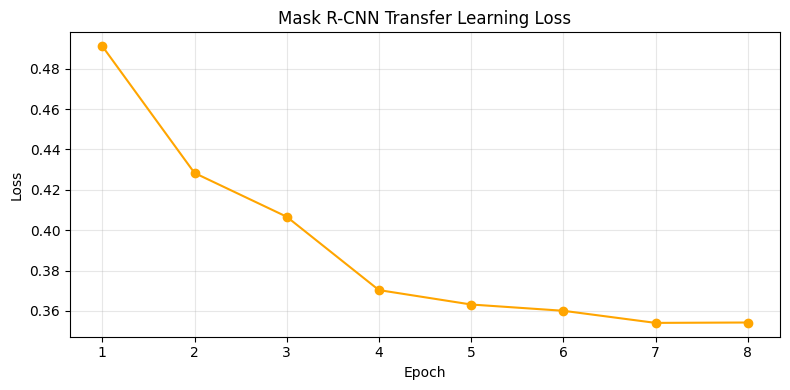

Loss curve saved.


In [10]:
torch.save(model.state_dict(), "/kaggle/working/maskrcnn_transfer.pth")
print("Saved: maskrcnn_transfer.pth")

with open("/kaggle/working/transfer_train_time.json", "w") as f:
    json.dump({"train_time_seconds": train_time}, f)

plt.figure(figsize=(8,4))
plt.plot(range(1, EPOCHS+1), train_losses, marker="o", color="orange")
plt.title("Mask R-CNN Transfer Learning Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("/kaggle/working/transfer_loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved.")

In [11]:
model.eval()
os.makedirs("/kaggle/working/visuals_transfer", exist_ok=True)
COLORS = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(255,0,255)]

for idx in range(min(3, len(val_data))):
    sample = val_data[idx]
    img    = cv2.imread(sample["img_path"])
    img    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img    = cv2.resize(img, (512, 512))
    inp    = F.to_tensor(Image.fromarray(img)).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(inp)[0]

    vis = img.copy()
    for i in range(len(pred["boxes"])):
        score = pred["scores"][i].item()
        if score < 0.3: continue
        box   = pred["boxes"][i].cpu().numpy().astype(int)
        lbl   = pred["labels"][i].item()
        mask  = pred["masks"][i, 0].cpu().numpy() > 0.5
        color = COLORS[(lbl - 1) % len(COLORS)]
        vis[mask] = (vis[mask]*0.5 + np.array(color)*0.5).astype(np.uint8)
        cv2.rectangle(vis, (box[0],box[1]), (box[2],box[3]), color, 2)
        cv2.putText(vis, f"{CLASS_NAMES[lbl]} {score:.2f}",
                    (box[0], max(box[1]-5,10)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    plt.figure(figsize=(8,6)); plt.imshow(vis); plt.axis("off")
    plt.title(f"Transfer Learning — Sample {idx+1}")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/visuals_transfer/pred_{idx+1}.png", dpi=150)
    plt.close()

print("Visuals saved.")
print("Output files:", os.listdir("/kaggle/working"))

Visuals saved.
Output files: ['label_map.json', '__notebook__.ipynb', 'transfer_train_time.json', 'visuals_transfer', 'maskrcnn_transfer.pth', 'transfer_loss_curve.png']
